# Analyse Results of Varying Sample Rates For Sample Methods


In [6]:
import sys
from pathlib import Path

project_root = Path("..")
sys.path.append(str(project_root))

## Initialise Results Analyser to Calculate Accuracies


In [7]:
from src.utils.results_analysis import ResultsAnalyser
from src.utils.constants import RESULTS_DIR

analyser_ucf_mgsampler = ResultsAnalyser(RESULTS_DIR / "ucf101_mgsampler_sample_rates")
analyser_ucf_uniform = ResultsAnalyser(RESULTS_DIR / "ucf101_uniform_sample_rates")
analyser_actn_mgsampler = ResultsAnalyser(
    RESULTS_DIR / "activitynet_mgsampler_sample_rates"
)
analyser_actn_uniform = ResultsAnalyser(
    RESULTS_DIR / "activitynet_uniform_sample_rates"
)

In [8]:
import regex as re
import numpy as np
import matplotlib.pyplot as plt

# hardcoded, these match the sample rates of the pipelines in the results
x = [1, 2, 4, 8, 16, 32, 64, 128]

# here I use the regex to extract the sample rate from the sampler's name in the pipeline name. This sample rate is then used to plot the accuracy.
regx = re.compile("[a-zA-Z]*([0-9]+).*")

acc_ucf_mgsampler = [None] * len(x)
for row in analyser_ucf_mgsampler.results_table:
    sample_rate = int(regx.match(row["model"]).group(1))
    acc_ucf_mgsampler[x.index(sample_rate)] = row["Top-1"]

acc_ucf_uniform = [None] * len(x)
for row in analyser_ucf_uniform.results_table:
    sample_rate = int(regx.match(row["model"]).group(1))
    acc_ucf_uniform[x.index(sample_rate)] = row["Top-1"]

acc_actn_mgsampler = [None] * len(x)
for row in analyser_actn_mgsampler.results_table:
    sample_rate = int(regx.match(row["model"]).group(1))
    acc_actn_mgsampler[x.index(sample_rate)] = row["Top-1"]

acc_actn_uniform = [None] * len(x)
for row in analyser_actn_uniform.results_table:
    sample_rate = int(regx.match(row["model"]).group(1))
    acc_actn_uniform[x.index(sample_rate)] = row["Top-1"]


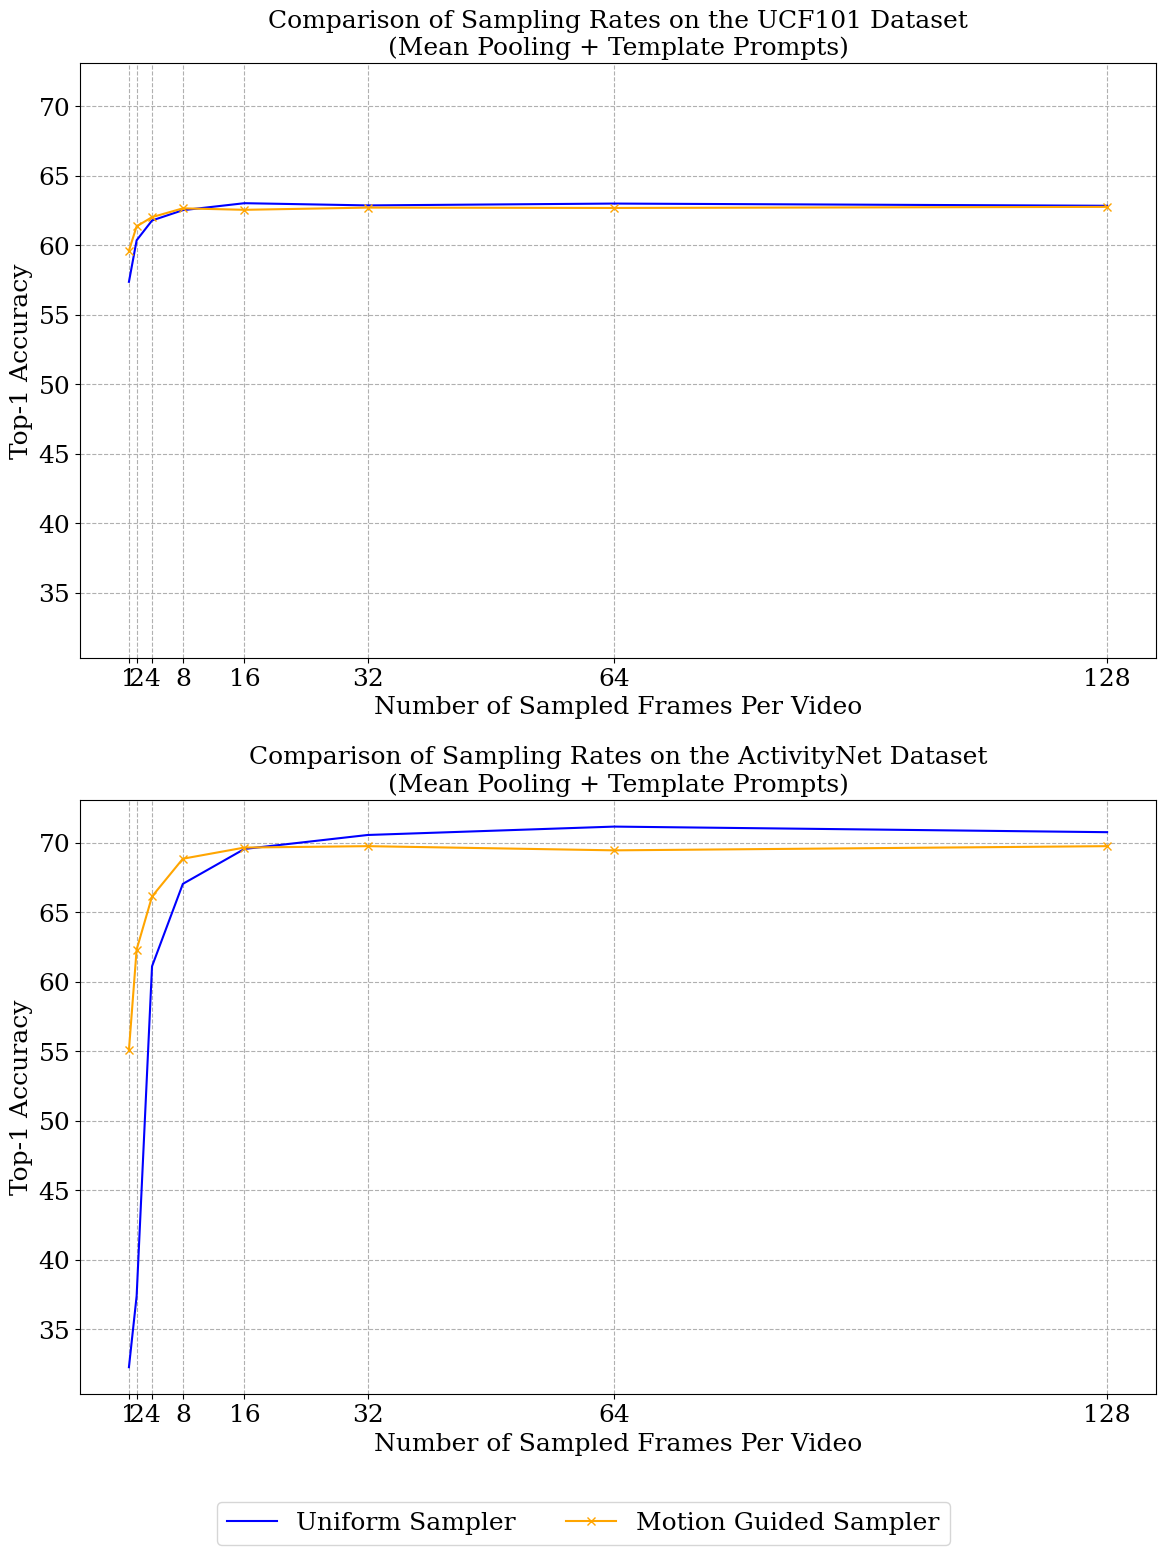

In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 15), sharey=True)

xlabel = "Number of Sampled Frames Per Video"
ylabel = "Top-1 Accuracy"

# Plot UCF101 sample rates
ax1.plot(x, acc_ucf_uniform, label="Uniform Sampler", color="blue", marker="")
ax1.plot(
    x, acc_ucf_mgsampler, label="Motion Guided Sampler", color="orange", marker="x"
)

ax1.set_title(
    "Comparison of Sampling Rates on the UCF101 Dataset\n(Mean Pooling + Template Prompts)"
)
ax1.set_xlabel(xlabel)
ax1.set_ylabel(ylabel)

ax1.set_xticks(x)
ax1.grid(True, linestyle="--")

# Plot ActivityNet sample rates
ax2.plot(x, acc_actn_uniform, label="Uniform Sampler", color="blue", marker="")
ax2.plot(
    x, acc_actn_mgsampler, label="Motion Guided Sampler", color="orange", marker="x"
)

ax2.set_title(
    "Comparison of Sampling Rates on the ActivityNet Dataset\n(Mean Pooling + Template Prompts)"
)
ax2.set_xlabel(xlabel)
ax2.set_ylabel(ylabel)

ax2.set_xticks(x)
ax2.grid(True, linestyle="--")

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.05), ncol=2)

font_size = 18
plt.rcParams.update(
    {
        "font.size": font_size,
        "axes.titlesize": font_size,
        "axes.labelsize": font_size,
        "xtick.labelsize": font_size,
        "ytick.labelsize": font_size,
        "legend.fontsize": font_size,
        "font.family": "serif",
    }
)

plt.tight_layout()
plt.show()